# Can an AI trade stocks? I built a test to find out.

*A plain-language walk through one experiment. No maths beyond percentages, no code you need to read — each short code cell just draws the next picture. If you want the full technical version, it is in `03_new_rule_model_comparison.ipynb`; the code is in the `alphabench/` folder.*

**The question.** Websites like Alpha Arena and TradeRank.ai let AI language models trade pretend money and rank them by how much they made. A model at the top of such a list looks clever. But is it? A rising market lifts everyone, a lucky bet lifts anyone, and the leaderboard never asks. I wanted a way to tell skill from luck.

**The short answer, so you can stop here if you like.** Over one summer, with two AI models — a small one that runs on my laptop and one of the largest available, GPT-5.1 — and three different sets of instructions, nothing beat the dullest strategy there is: buying all fifty stocks and doing nothing. The one result that looked impressive turned out to be a single lucky bet. The big model followed the rules far better than the small one and made less money. And both models said they were more than 80% sure of every trade they made, while between one in seven and one in three made money.

The rest of this notebook shows how I know that.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from alphabench.report import *          # the pictures; everything is read from data/summary/
S = load_summary(ROOT)
print("Runs in this story:", *[f"{v['label']} — {S.window(k)}" for k, v in S.meta["runs"].items()], sep="\n  ")

Runs in this story:
  leaderboard rules (no position limit) — 1 June to 26 August 2026, 60 trading days
  25% position limit — 1 June to 26 August 2026, 60 trading days


## 1. The game

I built a small simulator that plays a stock-trading game, and let different players take turns at it. The rules are the same as on the leaderboards, plus one I added later (section 5):

- **$10,000 of pretend money**, 50 large US companies (Apple, Microsoft, and so on), 60 trading days from June to August 2026.
- **One decision a day**, after the market closes, carried out at the next morning's opening price — so nobody can peek at prices they could not have known.
- **One new position per day, at most ten at a time.** A player may bet on a stock going up (*long*) or down (*short*).
- **Every bet needs a stop-loss**: a price at which the simulator closes it automatically if it goes the wrong way.
- **Every trade costs 0.1%**, like a real broker.
- A player may **add to a bet that is already winning**, but never to one that is losing.

Every player sees the same information: the last few weeks of prices and a few simple statistics for each stock, plus their own account. Nothing else. No news, no earnings, no internet.

## 2. The players

**Three AI players.** The same AI model each time (Qwen3, an 8-billion-parameter open model that runs on my laptop; a much larger model joins in section 6), with three different sets of instructions, or *prompts*:

- **Prompt 1** — the instructions copied from the leaderboards: manage the account, explain each bet, set a stop-loss.
- **Prompt 2** — the same, plus some risk rules: how big a bet should be, how far away the stop-loss belongs.
- **Prompt 3** — a full step-by-step procedure: check your existing positions first, score each stock on four criteria, only bet when it clearly beats doing nothing.

**Two players that are not AI at all.** They are there so we can tell whether the AI is doing anything a simpler thing could not:

- **A one-line rule**: buy whatever went up most in the last ten days, sell it when it stops going up.
- **Do nothing**: buy all 50 stocks in equal amounts on day one and hold. Also the S&P 500 index fund, for reference.

**And 1,000 coin-flippers.** These are the key to the whole experiment. Each one plays by the same rules, but decides everything at random: whether to trade today, which stock, up or down, how much. They have no information and no skill. If an AI player finishes ahead of most of them, that means something; if it finishes in the middle of the pack, it has shown nothing that a coin would not.

## 3. What happened — under the leaderboard's rules

First I ran the game exactly as the leaderboards do. Here is the value of each player's account over the summer, starting at 100.

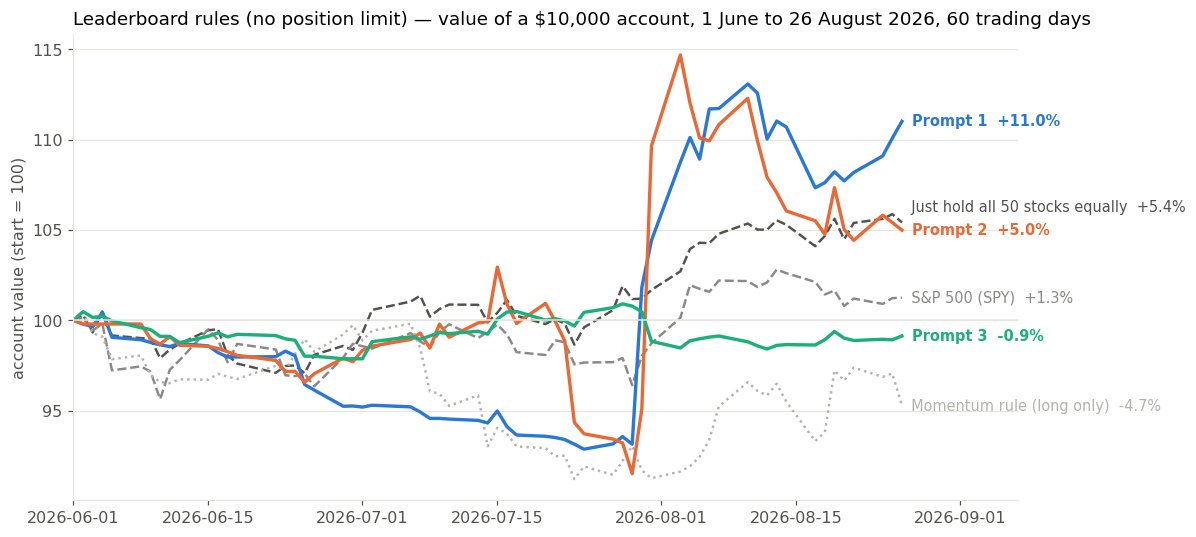

In [2]:
equity_chart(S, "leaderboard_rules");

Prompt 1, the leaderboard's own instructions, finished up 11%. That beats the do-nothing strategy (+5.4%), the S&P 500 (+1.3%) and the simple rule (−4.7%). On a leaderboard, Prompt 1 would be the winner.

The scoreboard adds three columns the leaderboards do not show: how many trades each player made, how many of them made money, and how big its biggest single bet was.

In [3]:
scoreboard(S, "leaderboard_rules")

,Result,Trades,Winning trades,Biggest single bet,Random traders beaten
Who,,,,,
Prompt 1 — leaderboard mandate,+11.0%,17,12%,100% of the account,98 in 100
Prompt 2 — plus risk rules,+5.0%,5,20%,100% of the account,88 in 100
Prompt 3 — full decision procedure,-0.9%,5,20%,20% of the account,60 in 100
Momentum rule (long only),-4.7%,51,41%,10% of the account,29 in 100
Just hold all 50 stocks equally,+5.4%,—,—,—,88 in 100
S&P 500 (SPY),+1.3%,—,—,—,73 in 100


Two things stand out. Prompt 1 won only 2 of its 17 trades. And its biggest bet was the *whole account* in one stock. That is worth a closer look.

## 4. Where the +11% came from

Here is every trade Prompt 1 made, in order, with its profit or loss.

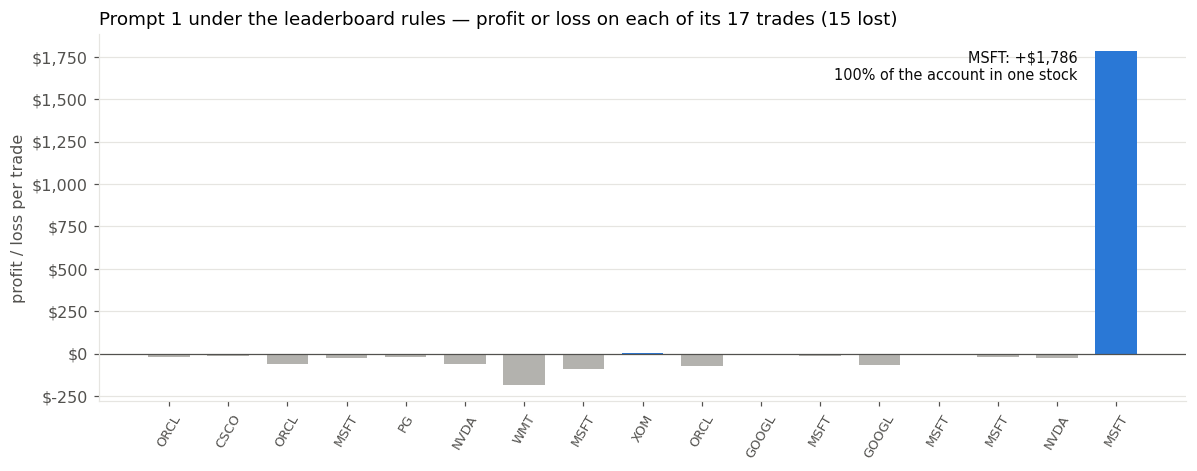

In [4]:
one_bet_chart(S);

Fifteen of seventeen trades lost money. One made $5. The seventeenth made $1,786 — and that one trade is the entire result. What happened: the model bought Microsoft, and then, because the rules allow adding to a winning bet, it kept adding, day after day, until almost the whole account was in that one stock. Microsoft then rose 19% in a month. Take that one trade away and Prompt 1 lost money.

Prompt 2 did the same thing with Amazon. Prompt 3, told to size every bet at 10–20% of the account, never piled in, and made nothing.

**Was piling in a clever decision?** This is what the coin-flippers are for. The chart below shows where 500 of them ended up when they, too, were allowed to keep adding to winners. Each bar is a number of random traders who finished with that result; the blue line is Prompt 1.

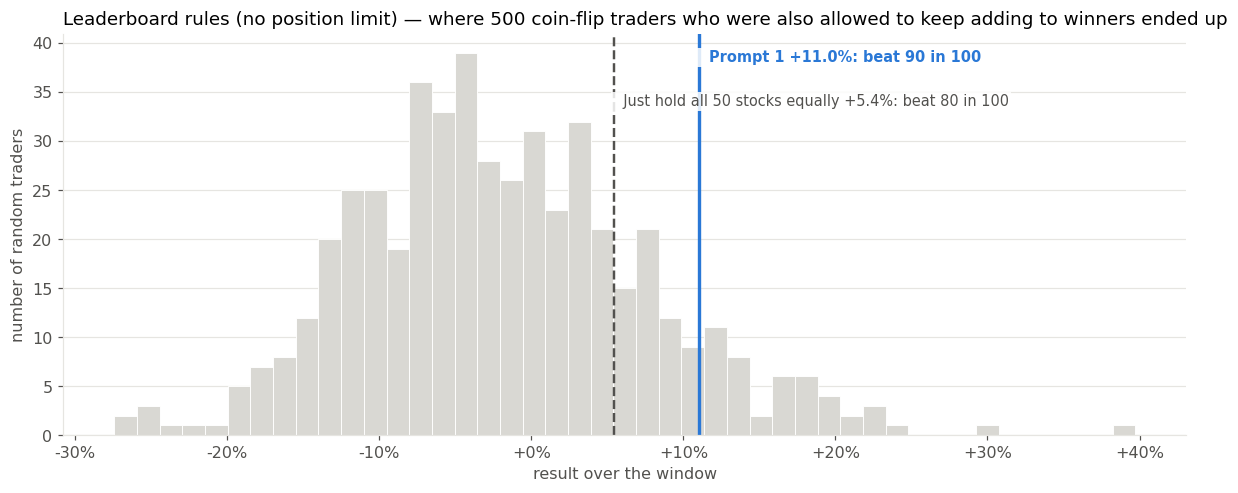

In [5]:
luck_chart(S, "leaderboard_rules", pyramiding=True, agents=[PROMPTS[0], INDEX]);

About one random trader in ten did as well as Prompt 1 or better, with no information at all. That is the kind of result a coin produces one time in ten — and Prompt 1 was the best of three prompts I tried, which is roughly how often you would expect to find one. "Beat 90 in 100" sounds strong; against a coin that can pile into a winner, it is one lucky summer.

There is a second, simpler problem: no real fund would ever let a manager put nearly all of the money into one stock. The leaderboard's rules allow it, so their winners can be whoever bet biggest on the stock that happened to go up.

## 5. Adding the rule any real account has

So I added one rule to the game: **no single stock may be more than 25% of the account.** The simulator enforces it on every player — the three AI prompts, the simple rule, and all the coin-flippers — and every prompt is told about it. Then I ran the whole summer again.

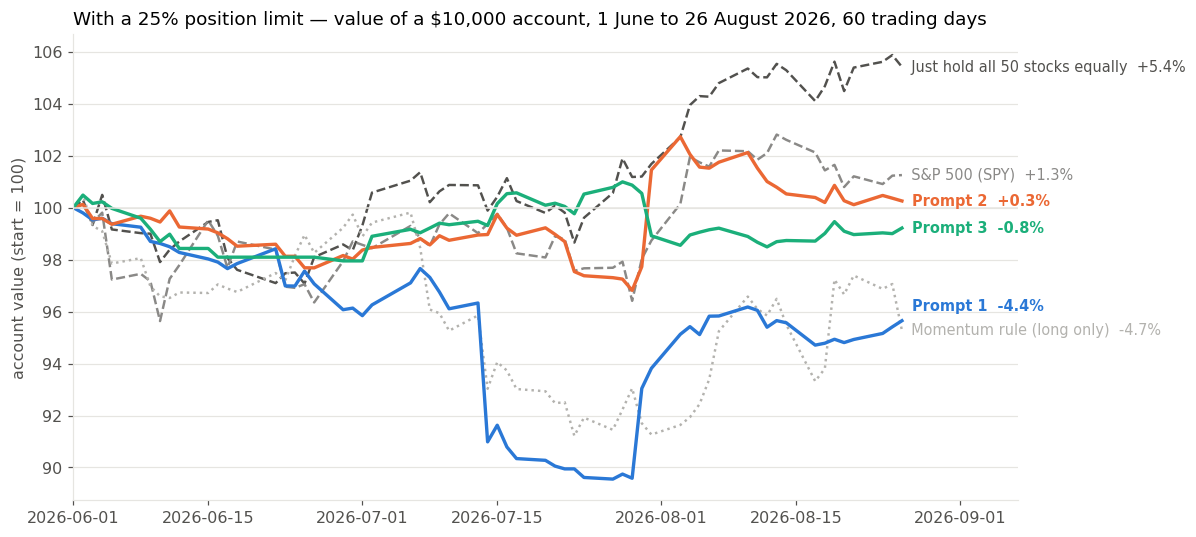

In [6]:
equity_chart(S, "position_limit");

In [7]:
scoreboard(S, "position_limit")

,Result,Trades,Winning trades,Biggest single bet,Random traders beaten
Who,,,,,
Prompt 1 — leaderboard mandate,-4.4%,14,7%,25% of the account,29 in 100
Prompt 2 — plus risk rules,+0.3%,4,25%,25% of the account,65 in 100
Prompt 3 — full decision procedure,-0.8%,5,20%,20% of the account,57 in 100
Momentum rule (long only),-4.7%,51,41%,10% of the account,26 in 100
Just hold all 50 stocks equally,+5.4%,—,—,—,91 in 100
S&P 500 (SPY),+1.3%,—,—,—,73 in 100


With the limit in place, the +11% disappears. Prompt 1 tried to add to its positions 37 times; the rule refused 24 of those and cut the rest down to size. It finished at −4.4%, with one winning trade in fourteen. Prompt 2 ended flat, Prompt 3 slightly down. Doing nothing still made +5.4%.

Here are the three prompts before and after the rule, side by side.

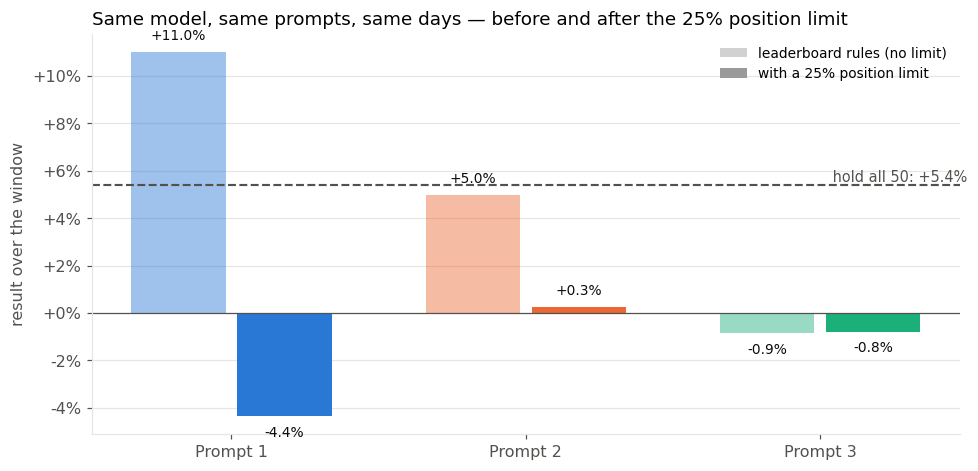

In [8]:
before_after_chart(S);

And here is where they land among 500 coin-flippers playing under the same rule.

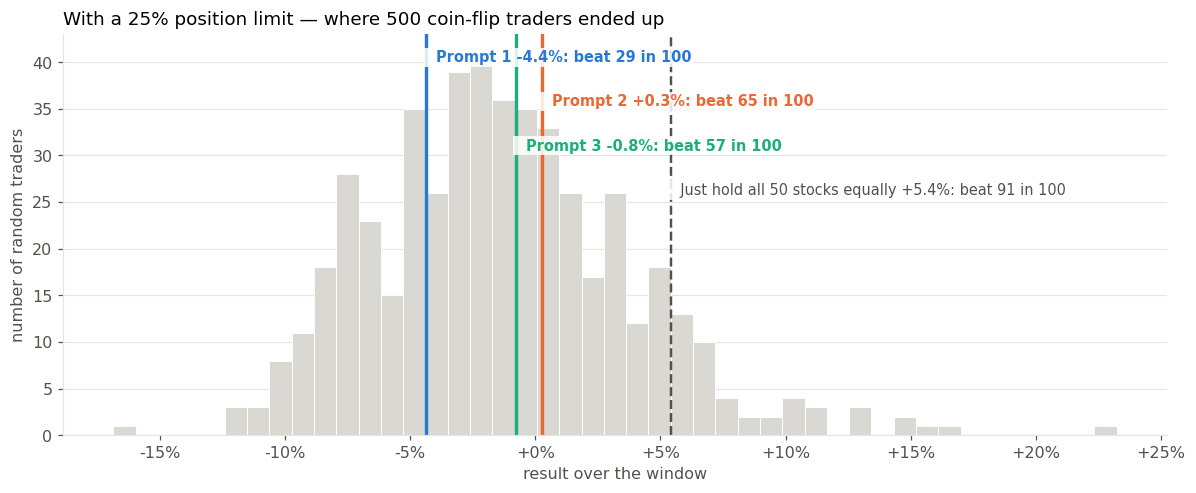

In [9]:
luck_chart(S, "position_limit");

All three prompts sit in the middle of the pack, somewhere between beating 30 and 65 random traders in 100. That is the range a coin-flipper lands in most of the time. The do-nothing strategy beat 91 in 100 — without making a single decision.

## 6. Is it just because the model is small?

The obvious objection to everything so far: Qwen3 8B is a small model that fits on a laptop, and the models on the leaderboards are a hundred times larger. So I gave the same three prompts, the same 60 days, the same 50 stocks and the same 25% limit to GPT-5.1, one of the largest models available, through OpenAI's API. Three full runs cost $3.39 and took 45 minutes.

The bold lines are GPT-5.1; the faint ones are the small model from section 5.

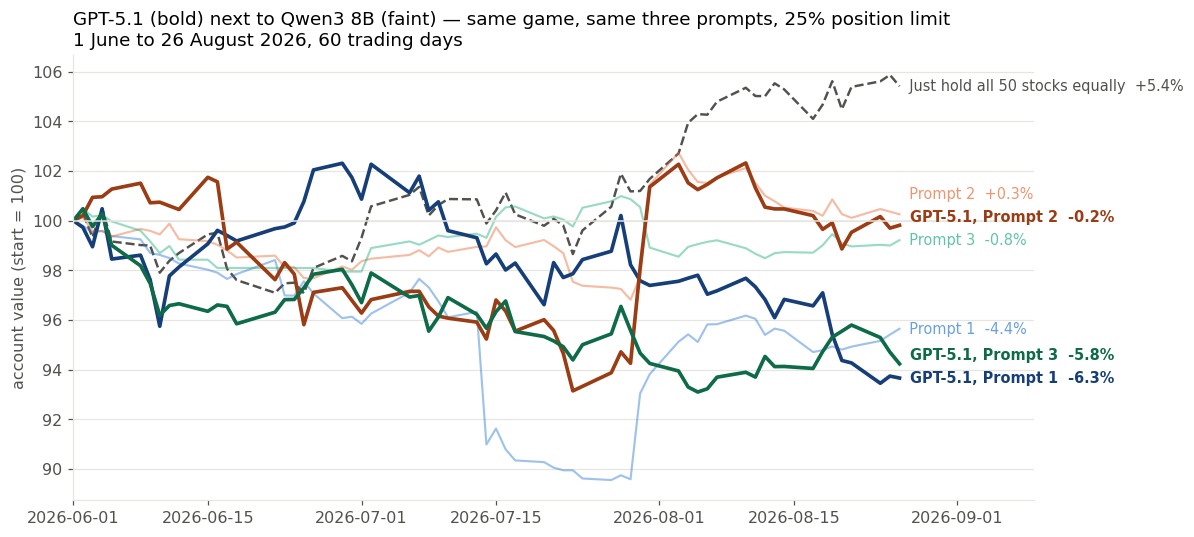

In [10]:
model_chart(S);

In [11]:
scoreboard(S, "position_limit", agents=PROMPTS_GPT + PROMPTS + [INDEX])

,Result,Trades,Winning trades,Biggest single bet,Random traders beaten
Who,,,,,
"GPT-5.1, Prompt 1 — leaderboard mandate",-6.3%,15,27%,25% of the account,18 in 100
"GPT-5.1, Prompt 2 — plus risk rules",-0.2%,12,33%,25% of the account,63 in 100
"GPT-5.1, Prompt 3 — full decision procedure",-5.8%,23,17%,20% of the account,20 in 100
Prompt 1 — leaderboard mandate,-4.4%,14,7%,25% of the account,29 in 100
Prompt 2 — plus risk rules,+0.3%,4,25%,25% of the account,65 in 100
Prompt 3 — full decision procedure,-0.8%,5,20%,20% of the account,57 in 100
Just hold all 50 stocks equally,+5.4%,—,—,—,91 in 100


The big model made less money, not more: −6.3%, −0.2% and −5.8% against the small model's −4.4%, +0.3% and −0.8%. Doing nothing still made +5.4%. Against the coin-flippers, its three prompts beat 18, 63 and 20 in 100 — and because GPT-5.1 never once bet on a stock falling, the fairer comparison is with the 500 coin-flippers who only ever bought, and there it beat 5, 37 and 8 in 100. Two of its three prompts finished near the bottom of the pack.

What *did* change is how it played. This table comes from the trade logs; read it as habits rather than results.

In [12]:
behaviour_table(S)

,Model,Result,Days it chose to do nothing,Trades,Bets on a fall (short),Winning trades,Stopped out,Closed by choice,Average days held,Biggest single bet
Who,,,,,,,,,,
Prompt 1 — leaderboard mandate,Qwen3 8B (laptop),-4.4%,7 of 60,14,1,7%,12,1,5,25%
Prompt 2 — plus risk rules,Qwen3 8B (laptop),+0.3%,13 of 60,4,0,25%,2,1,20,25%
Prompt 3 — full decision procedure,Qwen3 8B (laptop),-0.8%,55 of 60,5,1,20%,4,0,13,20%
"GPT-5.1, Prompt 1 — leaderboard mandate",GPT-5.1 (OpenAI API),-6.3%,43 of 60,15,0,27%,5,5,23,25%
"GPT-5.1, Prompt 2 — plus risk rules",GPT-5.1 (OpenAI API),-0.2%,38 of 60,12,0,33%,5,3,28,25%
"GPT-5.1, Prompt 3 — full decision procedure",GPT-5.1 (OpenAI API),-5.8%,28 of 60,23,0,17%,5,14,18,20%


GPT-5.1 broke the rules almost never, where most of what the small model asked for under Prompts 1 and 2 had to be refused by the simulator. It sized every bet by itself, placed its stop-losses further away so it was stopped out less often, held for weeks rather than days, and when told to follow the full step-by-step procedure it did more with it, not less — 23 trades, and 14 positions closed by its own choice rather than by the stop-loss. That is a model that does what it is told, precisely.

The trouble is what it was told to do with prices alone. A model that follows a careful procedure on a signal that is not there produces a tidy sequence of small losses: 19 of its 23 trades under Prompt 3 lost money, most of them closed by choice at −1% to −5% before the stop-loss was hit, and its two largest winners were still open when the summer ended. Being a hundred times larger changed the manners, not the result.

## 7. Did the models know when they were right?

Every time an AI player made a bet, it also had to say how confident it was, as a number between 0 and 1. This is the part of the experiment I care about most, because a model that *knows* when it is unsure would be useful even if it were not a great trader: you could trust it more when it says 0.95 and less when it says 0.80.

Here is what each model said, next to what actually happened, for every prompt in every run.

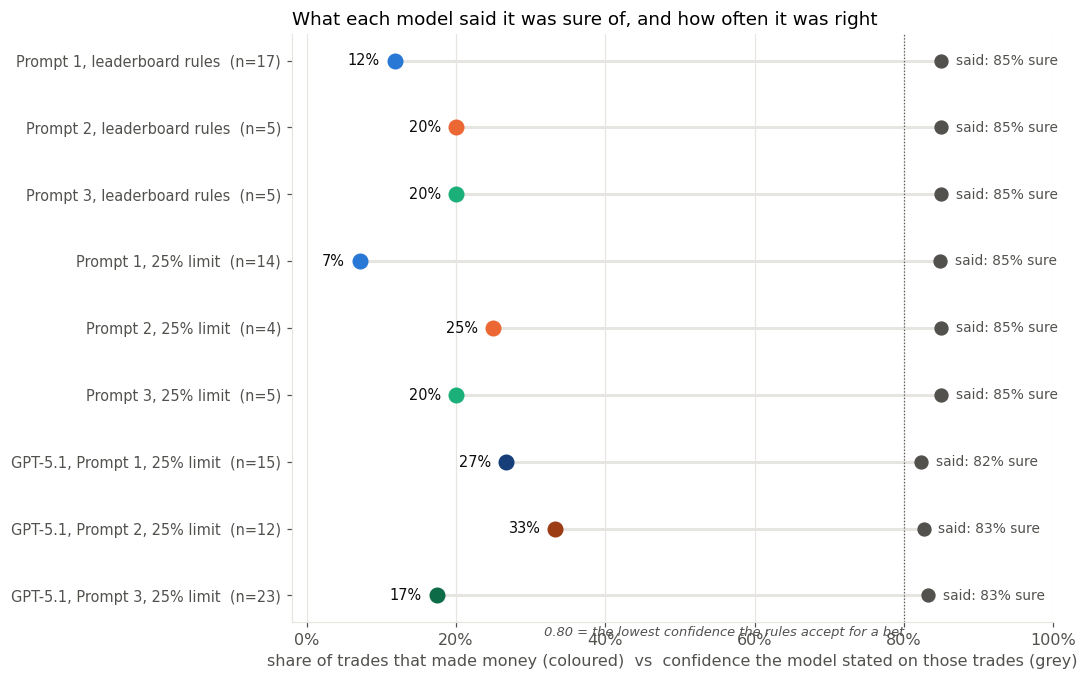

In [13]:
confidence_chart(S);

The small model said it was 85% sure on every trade — all 23 of them in this run, all 27 in the first, whatever stock, whatever the situation. GPT-5.1 said 81% to 84% on every one of its 50. In reality, between 7% and 33% of the trades made money.

Look at where the grey dots sit: just above the dotted line. The rules of the game say a bet needs a confidence of at least 0.80 to be placed, and that is exactly what both models wrote — the smallest number that gets the trade through. So the honest reading is not "the models are overconfident". It is that a confidence figure attached to the decision to act is answered as a permission slip, not as a forecast, and it tells you nothing about whether the model has any idea. That is partly a flaw in how I asked the question, and it is the first thing to change: ask for the forecast separately from the trade, with no threshold, and score it on its own.

Of the findings in this notebook, this is the one I would bet survives a longer test and a bigger model — it already survived one. The returns might change with a different summer. A confidence figure that barely moves cannot mean anything in any summer.

## 8. What this does and does not show

**What it shows.** Over one summer, nothing either AI model did beat holding the fifty stocks and waiting. The result that looked good was one bet that the rules should not have allowed. A model a hundred times larger followed the rules far better and made less. Neither model's confidence carried information, partly because of how the question was asked. And a leaderboard that only reports returns would have shown you none of this — it would have shown Prompt 1 at +11% and moved on.

**What it does not show.** That AI cannot trade. It is sixty days in a calm, rising market. The AI players made between 4 and 23 trades each, which is far too few to measure skill even if it were there — enough to rule out "clearly better than a coin", not enough to rule out a small edge. And the information they had — prices and a few statistics — is thin; a model given news or company filings is a different experiment. GPT-5.1 also ran at its lowest reasoning setting; more thinking time is untested here.

**What I would do next.** Give the models information that prices do not contain, starting with company filings, and watch whether their confidence starts to vary before watching the returns. Ask for the forecast separately from the trade. Run a full year, so each player makes enough trades to measure. And keep the three tests — a do-nothing benchmark, a thousand coin-flippers, and a check on stated confidence — because they are what turned a leaderboard number into an answer.

---

### Glossary

**Long / short.** A long bet makes money if the stock goes up; a short bet makes money if it goes down (you borrow the shares, sell them, and buy them back later, hopefully cheaper).

**Stop-loss.** A price at which a bet is closed automatically to cap the loss.

**Position limit.** A cap on how much of the account may be in one stock. The rule added in section 5.

**Coin-flipper / random trader.** A simulated player that follows all the rules but chooses at random. A thousand of them show the spread of results that pure luck produces, so a real player's result can be placed against it: "beat 90 in 100" means only one random trader in ten did better.

**Do-nothing strategy (equal-weight index).** Buy all 50 stocks in equal amounts on day one and never trade. The bar every active player has to clear.

**Prompt.** The written instructions given to the AI model before it sees the data.

**Stated confidence.** The probability the model attaches to each bet when it makes it. A well-calibrated model that says 0.85 should be right about 85% of the time.

### Where the numbers come from

Everything in this notebook is read from `data/summary/`, a small set of tables written by `scripts/export_summary.py` from the two full runs (`03_model_comparison.ipynb` without the position limit, `03_new_rule_model_comparison.ipynb` with it — the second also holds the GPT-5.1 runs). Those notebooks contain the complete tables, the code that produced them, and the caveats in full.